# Mã hóa dữ liệu cho bài toán classification

Ở bước này, dựa trên data đã được clean ở trên ta sẽ tiến hành mã hóa như sau 

1. Gộp text ở 3 trường `title`, `description`, `content`

In [1]:
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv(r"..\\data\\vnexpress_clean_data.csv")

# Gộp các trường text thành một cột duy nhất
df["full_text"] = (
    df["title"].fillna("") + " " +
    df["description"].fillna("") + " " +
    df["content"].fillna("")
)

# Xem thử kết quả
df[["title", "description", "content", "full_text"]].head()

,title,description,content,full_text
0,Không khí lễ hội xuân một thế kỷ trước qua ảnh,Cảnh người dân tham gia lễ hội đền Hai Bà Trưn...,"Dịp đầu năm, nhiều lễ hội truyền thống được tổ...",Không khí lễ hội xuân một thế kỷ trước qua ảnh...
1,Kanye West thừa nhận bị rối loạn tâm thần,Rapper Kanye West cho biết mắc rối loạn lưỡng ...,Trên trang quảng cáo của tờWall Street Journal...,Kanye West thừa nhận bị rối loạn tâm thần Rapp...
2,Katy Perry quấn quýt cựu Thủ tướng Canada,Katy Perry và bạn trai - cựu Thủ tướng Justin ...,"TrênInstagramngày 10/2, Katy Perry chia sẻ loạ...",Katy Perry quấn quýt cựu Thủ tướng Canada Katy...
3,Sỏi to 'bằng nắm tay' trong bàng quang người đ...,"TP HCMÔng Ngọc, 69 tuổi, có sỏi bàng quang 10 ...",Ông Ngọc đến Bệnh viện Đa khoa Tâm Anh TP HCM ...,Sỏi to 'bằng nắm tay' trong bàng quang người đ...
4,Cuộc đua phim Việt Tết Bính Ngọ,Thị trường phim Việt sôi động với bốn tác phẩm...,"Trước ngày khởi chiếu 17/2 (mùng Một Tết), bốn...",Cuộc đua phim Việt Tết Bính Ngọ Thị trường phi...


2. Vector hóa `full_text` bằng công cụ TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

#load file stopword của tiếng Việt 
with open("..\\data\\vietnamese-stopwords.txt", encoding="utf-8") as f:
    vietnamese_stopwords = f.read().splitlines()

# Khởi tạo TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000, # giới hạn từ trong full_text
    ngram_range=(1, 2), # một số từ phải đi một cặp với nhau mới có nghĩa ví dụ "giải" + "trí" = "giải trí" 
    min_df=2, # các từ phải xuất hiện trong ít nhất 3 bài báo mới giữ lại
    token_pattern=r"(?u)\b[a-zA-ZÀ-ỹ_]+\b",
    ### Giữ lại các kí tự và các chữ tiếng việt 
    ### bởi các con số không có ý nghĩa cho bài toán phân loại này
    stop_words=vietnamese_stopwords #Thêm các stopword 
)

# Vector hóa cột full_text
X_text = vectorizer.fit_transform(df["full_text"])

# Kiểm tra kết quả
print("TF-IDF matrix shape:", X_text.shape)

# Xem thử một số từ trong vocabulary
print(vectorizer.get_feature_names_out()[3:20])

TF-IDF matrix shape: (1038, 5000)
['after' 'album' 'an' 'an nhiên' 'an ninh' 'an toàn' 'and' 'angelababy'
 'angeles' 'angelina' 'angelina jolie' 'ap' 'apple' 'art' 'asean' 'asia'
 'australia']


Trực quan hóa, xem thử các từ quan trọng 

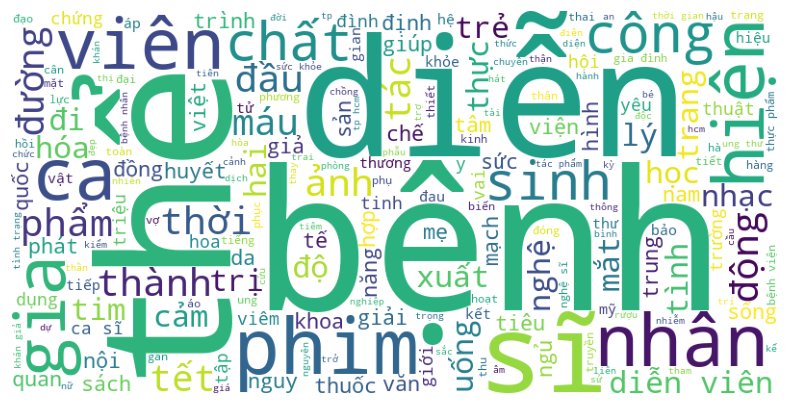

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Lấy tổng TF-IDF của mỗi từ
import numpy as np
tfidf_scores = np.asarray(X_text.sum(axis=0)).ravel()

# Lấy vocabulary
words = vectorizer.get_feature_names_out()

# Tạo dictionary word → score
word_scores = dict(zip(words, tfidf_scores))

# WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    collocations=False
).generate_from_frequencies(word_scores)

plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.axis("off")
plt.show()

3. Mã hóa nhãn các nhóm

In [22]:
from sklearn.preprocessing import LabelEncoder

# Khởi tạo encoder
label_encoder = LabelEncoder()

# Encode cột group
y = label_encoder.fit_transform(df["group"])

# Kiểm tra mapping
print("Label mapping:")
for label, index in zip(label_encoder.classes_, range(len(label_encoder.classes_))):
    print(label, "->", index)

# Xem thử một vài label đã encode
print("Encoded labels:", y[:10])

Label mapping:
Giải trí -> 0
Khác -> 1
Sức khỏe -> 2
Encoded labels: [1 1 1 1 1 1 1 1 1 1]


Xem phân bố trong không gian vector

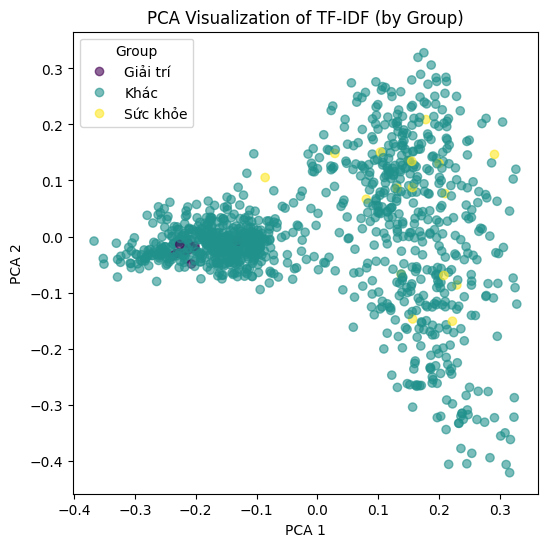

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# chuyển sparse -> dense
X_dense = X_text.toarray()

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_dense)

# encode group thành số
groups = df["group"].astype("category")
colors = groups.cat.codes

# plot
plt.figure(figsize=(6,6))
scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=colors,
    alpha=0.6
)

# legend
handles, _ = scatter.legend_elements()
plt.legend(handles, list(groups.cat.categories), title="Group")

plt.title("PCA Visualization of TF-IDF (by Group)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()